In [1]:
import numpy as np
from embedding_class import synthetic_data_generation, observation_map,embedding, MLE

# 1. Phase 4: Kalman Filter Coupling and Nyström Lifting
### Kalman filter class

In [4]:
import numpy as np

class LinearKalmanFilter:
    def __init__(self, A, Q, H, R, Z0=None, P0=None):
        self.A = np.asarray(A)
        self.Q = np.asarray(Q)
        self.H = np.asarray(H)
        self.R = np.asarray(R)

        self.k = self.A.shape[0]

        if Z0 is None:
            Z0 = np.zeros(self.k)

        if P0 is None:
            P0 = np.eye(self.k)

        self.Ztm1_tm1 = np.asarray(Z0)
        self.Ptm1_tm1 = np.asarray(P0)

    def predict(self):
        self.Zt_tm1 = self.A @ self.Ztm1_tm1
        self.Pt_tm1 = self.A @ self.Ptm1_tm1 @ self.A.T + self.Q

        return self.Zt_tm1, self.Pt_tm1

    def update(self, z):
        z = np.asarray(z)

        S = self.H @ self.Pt_tm1 @ self.H.T + self.R
        K = self.Pt_tm1 @ self.H.T @ np.linalg.inv(S)
        self.Kt = K

        innovation = z - self.H @ self.Zt_tm1

        self.Zt_t = self.Zt_tm1 + K @ innovation
        self.Pt_t = (np.eye(self.k) - K @ self.H) @ self.Pt_tm1

        return self.Zt_t, self.Pt_t

    def one_step(self, z):
        self.predict()
        self.update(z)
        self.Ztm1_tm1 = self.Zt_t
        self.Ptm1_tm1 = self.Pt_t
        return self.Zt_t, self.Pt_t

    def run(self, Zobs):
        Zobs = np.asarray(Zobs)
        N = Zobs.shape[0]

        filtered = np.zeros((N, self.k))

        for i in range(N):
            Z_filt, _ = self.one_step(Zobs[i])
            filtered[i] = Z_filt

        return filtered

### Kalman filter class usage

In [7]:
LATENT_SEED, FEATURE_SEED, NOISE_SEED = 0, 1, 2
SIGMA_ETAS, DS = [0.0, 0.05, 0.1, 0.2], [50, 100]

# Get latent state on sphere
latent = synthetic_data_generation(rand_seed=LATENT_SEED)
latent.thin_trajectories(gap=10, burnin=500)

kappa = latent.kappa
sigma = latent.sigma
dt = latent.dt
T = latent.T
dt_eff = latent.dt_eff
gap = latent.gap

# Generate observations
obs = observation_map(latent.X_geom, D=100, feature_seed=FEATURE_SEED)
clean = obs.clean_state()
Zobs = obs.sample_observation(0.05)

# Get embedding
dm = embedding()
w, Psi_noisy = dm.get_embedding(Zobs, alpha=1, k=4)

# Embedding for g(Xt) without noise
w_clean, Psi_clean = dm.get_embedding(clean["Gclean"])

mle = MLE()
kappa_hat, sigma_hat, _, _ = mle.ou_mle(Psi_noisy[:, :2], dt_eff)


In [ ]:
k = 2
dt_eff = gap * dt

a = np.exp(-kappa_hat * dt_eff)

A = a * np.eye(k)

Q = (sigma_hat**2 / (2*kappa_hat)) * (1 - np.exp(-2*kappa_hat*dt_eff)) * np.eye(k)

H = np.eye(k)

R = np.cov((Psi_noisy[:, :k] - Psi_clean[:, :k]).T)

P0 = sigma_hat**2 / (2*kappa_hat) * np.eye(k)

kf = LinearKalmanFilter(A, Q, H, R, Z0=np.zeros(k), P0=P0)

filtered = kf.run(Psi_noisy[:, :k])

Text(0, 0.5, '1st Coordinate Position')

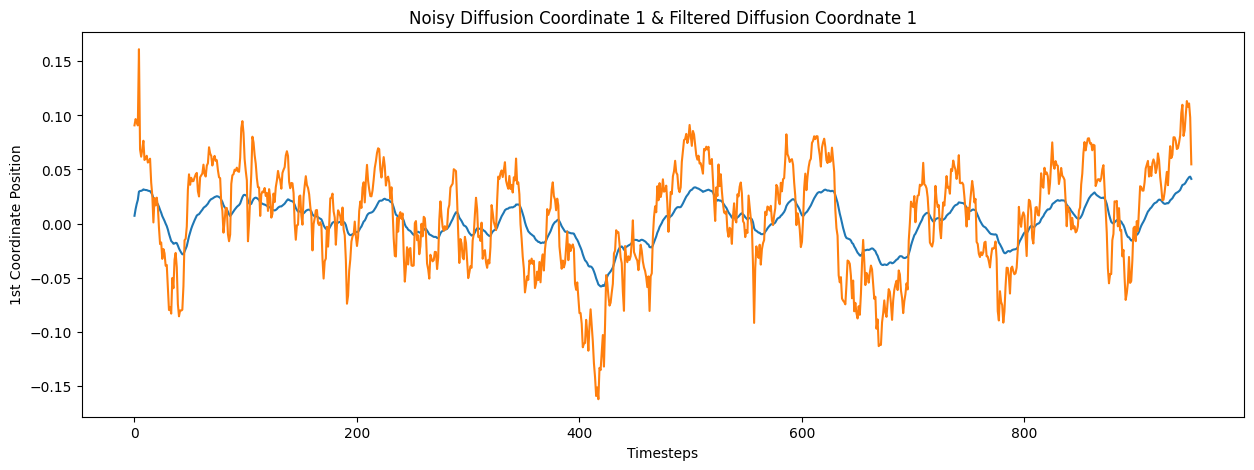

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(filtered[:, 0])
plt.plot(Psi_noisy[:, 0])
plt.title("Noisy Diffusion Coordinate 1 & Filtered Diffusion Coordnate 1")
plt.xlabel("Timesteps")
plt.ylabel("1st Coordinate Position")
